In [1]:
## Set up the input datasets

import sys
import os 

import pandas as pd

import numpy as np 

import matplotlib.pyplot as plt 

import time as time

import cv2 
from PIL import Image, ImageFilter

import random

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch import nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR


import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large, deeplabv3_resnet50
import torchvision.models as models

from tqdm import tqdm

In [2]:
# Load the CSV file with labels
labels_df = pd.read_csv("/kaggle/input/bhf-data-science-centre-ecg-challenge/train_final.csv")

# Some images are broken/unreadable
# Use these lines to only read in the "valid" images to stop 
with open('/kaggle/input/bhf-reference-files/valid_images_list.txt', 'r') as file:
    valid_image_paths = [line.strip() for line in file]

with open('/kaggle/input/bhf-reference-files/valid_test_images_list.txt', 'r') as file:
    valid_test_images = [line.strip() for line in file]

## Defining segmentation model

In [3]:
def generate_output(image: np.array, corners: np.ndarray, scale: tuple = None):
    """Generates a perspective-transformed output image."""
    corners = order_points(corners)  # Ensure correct point order

    if scale is not None:
        corners *= np.array(scale, dtype=np.float32)  # Vectorized multiplication

    destination_corners = find_dest(corners)  # Get transformation target points
    M = cv2.getPerspectiveTransform(corners, destination_corners)  # Perspective matrix

    max_width, max_height = map(int, destination_corners[2])  # Extract output size
    out = cv2.warpPerspective(image, M, (max_width, max_height), flags=cv2.INTER_LANCZOS4)

    return np.clip(out, 0, 255).astype(np.uint8)  # Ensure valid pixel values

def order_points(pts: np.ndarray) -> np.ndarray:
    """Rearranges points to: top-left, top-right, bottom-right, bottom-left."""
    pts = np.asarray(pts, dtype=np.float32)  # Ensure NumPy array
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)

    rect = np.zeros((4, 2), dtype=np.float32)
    rect[0] = pts[np.argmin(s)]  # Top-left
    rect[2] = pts[np.argmax(s)]  # Bottom-right
    rect[1] = pts[np.argmin(diff)]  # Top-right
    rect[3] = pts[np.argmax(diff)]  # Bottom-left

    return rect  # Already a NumPy array, no conversion needed

def find_dest(pts: np.ndarray) -> np.ndarray:
    """Computes destination points based on max width and height."""
    (tl, tr, br, bl) = pts  # Unpack ordered points

    # Compute max width and height
    width = int(max(np.linalg.norm(br - bl), np.linalg.norm(tr - tl)))
    height = int(max(np.linalg.norm(tr - br), np.linalg.norm(tl - bl)))

    return np.array([[0, 0], [width, 0], [width, height], [0, height]], dtype=np.float32)

## Build a custom dataset class and dataloaders

In [4]:
def image_preprocess_transforms(mean=(0.4611, 0.4359, 0.3905), std=(0.2193, 0.2150, 0.2109)):
    common_transforms = T.Compose([T.ToTensor(), T.Normalize(mean, std),])
    return common_transforms

def deep_learning_scan(og_image: np.array = None, 
                       trained_model=None, 
                       image_size=384, 
                       BUFFER=10, 
                       preprocess_transforms=image_preprocess_transforms(), 
                       device='cpu'):

    half = image_size // 2
    imH, imW, C = og_image.shape
    image_model = cv2.resize(og_image, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
    scale_x = imW / image_size
    scale_y = imH / image_size
    
    image_model = preprocess_transforms(image_model)
    image_model = torch.unsqueeze(image_model, dim=0)
    
    image_model = image_model.to('cpu')

    # # Device on CPU
    model_cpu = trained_model.to('cpu')
    model_cpu.eval()
    
    # Rest of your preprocessing remains the same, but use model_cpu
    with torch.no_grad():
        out = model_cpu(image_model)["out"]

    out = torch.argmax(out, dim=1, keepdims=True).permute(0, 2, 3, 1)[0].numpy().squeeze().astype(np.int32)
    r_H, r_W = out.shape

    out = np.pad(out * 255, pad_width=((half, half), (half, half)), mode='constant')

    # Edge Detection.
    canny = cv2.Canny(out.astype(np.uint8), 225, 255)
    canny = cv2.dilate(canny, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
    contours, _ = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if not contours: 
        return None

    page = max(contours, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(page, True)
    corners = cv2.approxPolyDP(page, epsilon, True)
    corners = np.concatenate(corners).astype(np.float32)

    corners[:, 0] -= half
    corners[:, 1] -= half
    corners[:, 0] *= scale_x
    corners[:, 1] *= scale_y
    
    if not (np.all(corners.min(axis=0) >= (0, 0)) and np.all(corners.max(axis=0) <= (imW, imH))):

        left_pad, top_pad, right_pad, bottom_pad = 0, 0, 0, 0

        box_corners = cv2.boxPoints(cv2.minAreaRect(corners.reshape((-1, 1, 2)))).astype(np.int32)

        box_x_min, box_y_min = np.min(box_corners, axis=0)
        box_x_max, box_y_max = np.max(box_corners, axis=0)

        # Find corner point which doesn't satify the image constraint
        # and record the amount of shift required to make the box
        # corner satisfy the constraint

        left_pad, right_pad = max(-box_x_min, 0) + BUFFER, max(box_x_max - imW, 0) + BUFFER
        top_pad, bottom_pad = max(-box_y_min, 0) + BUFFER, max(box_y_max - imH, 0) + BUFFER

        # # new image with additional zeros pixels
        # # adjust original image within the new 'image_extended'

        image_extended = np.pad(og_image, ((top_pad, bottom_pad), (left_pad, right_pad), (0, 0)), mode='constant')

        # shifting 'box_corners' the required amount
        box_corners[:, 0] += left_pad
        box_corners[:, 1] += top_pad

        corners = box_corners
        og_image = image_extended

    corners = sorted(corners.tolist())
    return generate_output(og_image, corners)

    
def get_model(model_path, device=None):
    checkpoints = torch.load(model_path, map_location=device, weights_only=True)
    model = deeplabv3_mobilenet_v3_large(num_classes=2, aux_loss=True).to(device)
    model.load_state_dict(checkpoints, strict=False)
    return model 

In [5]:
seg_model_path = '/kaggle/input/document-detection/pytorch/default/1/model_mbv3_iou_mix_2C049.pth'
seg_model = get_model(seg_model_path, 'cpu')

In [6]:
class ECG_Dataset(Dataset):
    def __init__(self, image_paths, label_df, transforms=None, preprocess_fn=None, 
                 seg_model=None, device='cpu', new_width=2500, new_height=1200):
        self.image_paths = image_paths
        self.labels_df = label_df
        self.transforms = transforms
        self.preprocess_fn = preprocess_fn
        self.device = device
        self.local_model = seg_model
        self.new_width = new_width 
        self.new_height = new_height

    def __len__(self): 
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image: {image_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.preprocess_fn is not None:
            image = self.preprocess_fn(image, self.local_model)
            
        image = Image.fromarray(image)
        image = image.resize((self.new_width, self.new_height), Image.LANCZOS)
        
        if self.transforms is not None:
            image = self.transforms(image)
        
        # Extract label
        filename = os.path.basename(image_path)
        index = int(filename.rsplit('_', 1)[-1].split('.')[0])
        row = self.labels_df[self.labels_df['ID'] == index].iloc[:, 1:].values
        label = torch.tensor(row, dtype=torch.float32)

        return image, label

In [7]:
class FastGaussianBlur(object):
    """Simplified Gaussian Blur using PIL's GaussianBlur filter"""
    def __init__(self, radius_range=(1, 3)):
        self.radius_min, self.radius_max = radius_range
    
    def __call__(self, img):
        radius = random.uniform(self.radius_min, self.radius_max)
        return img.filter(ImageFilter.GaussianBlur(radius=radius))

class FastPaperFoldEffect(object):
    """Simplified paper fold effect"""
    def __init__(self, max_intensity=0.3):
        self.max_intensity = max_intensity
    
    def __call__(self, img):
        img_tensor = T.ToTensor()(img)
        
        # Create single vertical or horizontal fold
        h, w = img_tensor.shape[1:]
        # is_vertical = random.random() > 0.5
        fold_pos = random.uniform(0.2, 0.8)
        
        # Simplified fold mask
        # if is_vertical:
        #     fold_pos_px = int(w * fold_pos)
        #     img_tensor[:, :, fold_pos_px-2:fold_pos_px+2] *= random.uniform(0.7, 0.9)
        # else: # horizontal: which we never have
        #     fold_pos_px = int(h * fold_pos)
        #     img_tensor[:, fold_pos_px-2:fold_pos_px+2, :] *= random.uniform(0.7, 0.9)

        fold_pos_px = int(w * fold_pos)
        img_tensor[:, :, fold_pos_px-2:fold_pos_px+2] *= random.uniform(0.7, 0.9)
        
        return T.ToPILImage()(img_tensor)

In [8]:
# Optimized transform pipeline
train_transform = T.Compose([
    # Resize early to reduce computation
    T.Resize((224, 224), interpolation=InterpolationMode.LANCZOS),
    
    # Basic augmentations (fast)
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandomRotation(degrees=3),
    
    # Custom effects (simplified)
    # T.RandomApply([FastGaussianBlur(radius_range=(1, 3))], p=0.3), # Blurring actually is quite rare in the data
    T.RandomApply([FastPaperFoldEffect(max_intensity=0.3)], p=0.3), # Randomly adds a fold to the paper 
    
    # Final transforms
    # T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x + torch.randn_like(x) * 0.02),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transform
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [9]:
# Create the datasets for training and validation
train_dataset = ECG_Dataset(valid_image_paths, labels_df, 
                            transforms=train_transform, 
                           preprocess_fn=deep_learning_scan, 
                           seg_model=seg_model)

val_dataset = ECG_Dataset(valid_test_images, labels_df, 
                          transforms=val_transform, 
                         preprocess_fn=deep_learning_scan, 
                         seg_model=seg_model)

# without the initial image segmentation model

# train_dataset = ECG_Dataset(valid_image_paths, labels_df, 
#                             transforms=train_transform, 
#                            preprocess_fn=None, 
#                            seg_model=seg_model)

# val_dataset = ECG_Dataset(valid_test_images, labels_df, 
#                           transforms=val_transform, 
#                          preprocess_fn=None, 
#                          seg_model=seg_model)

# Create the dataloaders 
train_dataloader = DataLoader(train_dataset, 
                             num_workers = 2,
                             shuffle = True, 
                             batch_size = 16,
                             pin_memory=True)

val_dataloader = DataLoader(val_dataset, 
                             num_workers = 2,
                             shuffle = True, 
                             batch_size = 16,
                             pin_memory=True)

16.870421648025513


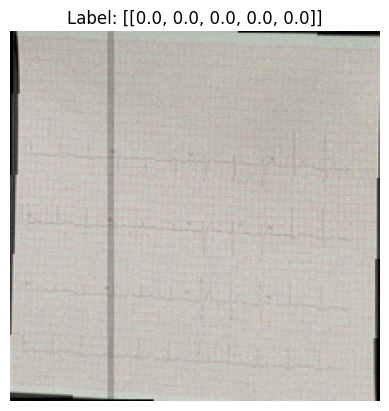

In [10]:
# Visualise an image from the dataloader and see whether it is sensible 
time_start = time.time()
dataiter = iter(train_dataloader)  # Get an iterator from the dataloader
image, label = next(dataiter)  # Get one batch
time_stop = time.time()

print(time_stop - time_start) 

# Convert the tensor to a NumPy array for visualization
image = image[0].permute(1, 2, 0).cpu().numpy()  # Convert (C, H, W) → (H, W, C)

# Unnormalize if needed (assuming mean=[0.5, 0.5, 0.5] and std=[0.5, 0.5, 0.5])
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]
image = image * std + mean  # Unnormalize
image = np.clip(image, 0, 1)  # Ensure values are in valid range

# Display the image
plt.figure()
plt.imshow(image)
plt.axis("off")
plt.title(f"Label: {label[0].tolist()}")
plt.show()

In [11]:
# Define a model 
# Start with a pretrained ResNet that we are going to fine tune with the ECG data 

model = models.resnet18(weights='DEFAULT')

# Freeze all layers except the last fully connected layer
for param in model.parameters():
    param.requires_grad = False

# Replace the last fully connected layer to suit the multi-label classification problem
model.fc = nn.Linear(model.fc.in_features, 5)  # 5 output classes for multi-label classification

# Now only the last layer will have its parameters updated
for param in model.fc.parameters():
    param.requires_grad = True

In [12]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, save_best_model=True, path='best_model.pth'):
        """
        Args:
            patience (int): Number of epochs to wait for improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            save_best_model (bool): Whether to save the best model based on validation loss.
            path (str): Path to save the best model.
        """
        self.patience = patience
        self.delta = delta
        self.save_best_model = save_best_model
        self.path = path
        self.counter = 0
        self.best_loss = float('inf')  # Initialize to a large number (worst case)
        self.early_stop = False
        self.best_model_wts = None  # To store best model weights

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0

            # Save the best model
            if self.save_best_model:
                self.best_model_wts = model.state_dict()
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.early_stop = True
            print(f"Early stopping triggered after {self.patience} epochs with no improvement in validation loss.")
            # Load the best weights
            if self.save_best_model:
                model.load_state_dict(self.best_model_wts)
            return True
        
        return False

In [13]:
# Set up the optimizer (only for the parameters of the last layer)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-5)  # Start with a very low learning rate

# Define the loss function (use BCEWithLogitsLoss for multi-label classification)
criterion = nn.BCEWithLogitsLoss()

# Learning Rate Scheduler: OneCycleLR
# Warm-up and decay the learning rate during training
scheduler = OneCycleLR(optimizer, max_lr=1e-3, total_steps=len(train_dataloader) * 20)  # Assuming 20 epochs

# Early Stopping
early_stopping = EarlyStopping(patience=5, delta=0.001, save_best_model=True, path='best_model.pth')

In [14]:
# work out device 
device = torch.device("mps" if torch.backends.mps.is_available() \
                      else ("cuda" if torch.cuda.is_available() 
                            else "cpu"))

print(device)

model = model.to(device)

cuda


In [15]:
# Set seeds for all sources of randomness
def set_seeds(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)


In [16]:
# Check model doesn't produce nonsense output 

set_seeds()

model.eval()

with torch.no_grad():
    image_path = '/kaggle/input/bhf-data-science-centre-ecg-challenge/train_1/train_encoded_relabelled/train_000005.png'
    image = Image.open(image_path).convert('RGB')
    image_tensor = train_transform(image).unsqueeze(0).to(device)  # Add batch dimension (1, C, H, W)
    output = model(image_tensor)
    row = labels_df[labels_df['ID'] == 5].iloc[:, 1:].values
    label = torch.tensor(row, dtype=torch.float32).to(device)
    loss = criterion(output, label)

print(type(output))
print(output.shape)
print(output)
print(label)
print(loss)

<class 'torch.Tensor'>
torch.Size([1, 5])
tensor([[-0.1287, -0.0185,  0.9211,  0.4601, -0.4482]], device='cuda:0')
tensor([[0., 0., 0., 1., 0.]], device='cuda:0')
tensor(0.7109, device='cuda:0')


In [17]:
num_epochs = 10

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    # Wrap the training loop with tqdm
    for inputs, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1} - Training", unit="batch"):
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.squeeze(1) # need to squeeze out odd dimension in labels
        
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update the optimizer
        optimizer.step()

        # Update the learning rate scheduler
        scheduler.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}")

    # Validation loop with tqdm
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in tqdm(val_dataloader, desc=f"Epoch {epoch+1} - Validation", unit="batch"):
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.squeeze(1) # need to squeeze out odd dimension in labels 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {avg_val_loss:.4f}")

    # Call early stopping
    if early_stopping(avg_val_loss, model):
        print(f"Training stopped early at epoch {epoch+1}")
        break

    # Unfreeze layers after epoch 5
    if epoch == 4:  # After epoch 5 (0-indexed)
        print("Unfreezing all layers after epoch 5.")
        for param in model.parameters():
            param.requires_grad = True

        # Reinitialize the optimizer for all layers now
        optimizer = optim.Adam(model.parameters(), lr=1e-5)

        # Set up the scheduler again for the remaining epochs
        scheduler = OneCycleLR(optimizer, max_lr=1e-3, total_steps=len(train_dataloader) * (num_epochs - epoch))

Epoch 1 - Training:   1%|          | 6/938 [01:09<3:00:56, 11.65s/batch]


KeyboardInterrupt: 

In [ ]:
# Save the model's state_dict (recommended)
torch.save(model.state_dict(), 'model.pth')

In [ ]:
# Check model doesn't produce nonsense output 

set_seeds()

model.eval()

with torch.no_grad():
    image_path = '/kaggle/input/bhf-data-science-centre-ecg-challenge/train_1/train_encoded_relabelled/train_000005.png'
    image = Image.open(image_path).convert('RGB')
    image_tensor = train_transform(image).unsqueeze(0).to(device)  # Add batch dimension (1, C, H, W)
    output = model(image_tensor)
    row = labels_df[labels_df['ID'] == 5].iloc[:, 1:].values
    label = torch.tensor(row, dtype=torch.float32).to(device)
    loss = criterion(output, label)

print(type(output))
print(output.shape)
print(output)
print(label)
print(loss)